# Домашнее задание 8. Мониторинг

Прослеживаемость конвейера (и кода, и данных) должна закладываться **до проектирования** (в идеале, на основе синтезированного трафика от системы нагрузочного тестирования Locust/k6s/ab/...).


## 1. Определить ключевые бизнес- и технические метрики для ML-системы

Чтобы разработка могла сдвинуться с мертвой точки, создайте сбаланисированное дерево метрик, которое бы учитывало точки зрения разных команд.


|Требования бизнеса|Требования разработчиков|Требования команды ML|Требования DevOps|
|------------------|------------------------|---------------------|-----------|
|Нужно увеличить выручку онлайн-кинотеатра|Нужен новый сервер |Нужен GPU      | Вы существующие мощности недогружаете |
|...пиковая нагрузка 10000 RPS|Нужно переходить на ClickHouse? |Сколько фильмов выводить для рекомендательной системы?      |Есть Postgres, он выдает 1000 RPS, потому что мы обернули Docker-in-Docker         |
|...и чтобы быстрый был|Нужно переписать бэкенд?|Нужно переходить на стримы? | Какое нужно время отклика? |
|...и чтобы надежный был| Сделать на Kubernetes? |Сделать на KubeFlow? | SLA 100% нет даже на бирже  |

Желательно использовать [adr-tools](https://github.com/npryce/adr-tools), чтобы записывать **причины**, по которым мы начали принимать решения и **риски**, из-за которых ML-система может работать не так, как ожидается.


*Ожидаемый артефакт: создающий диаграмму код в [ячейке](#scrollTo=y2v5KaAkw0zx)*

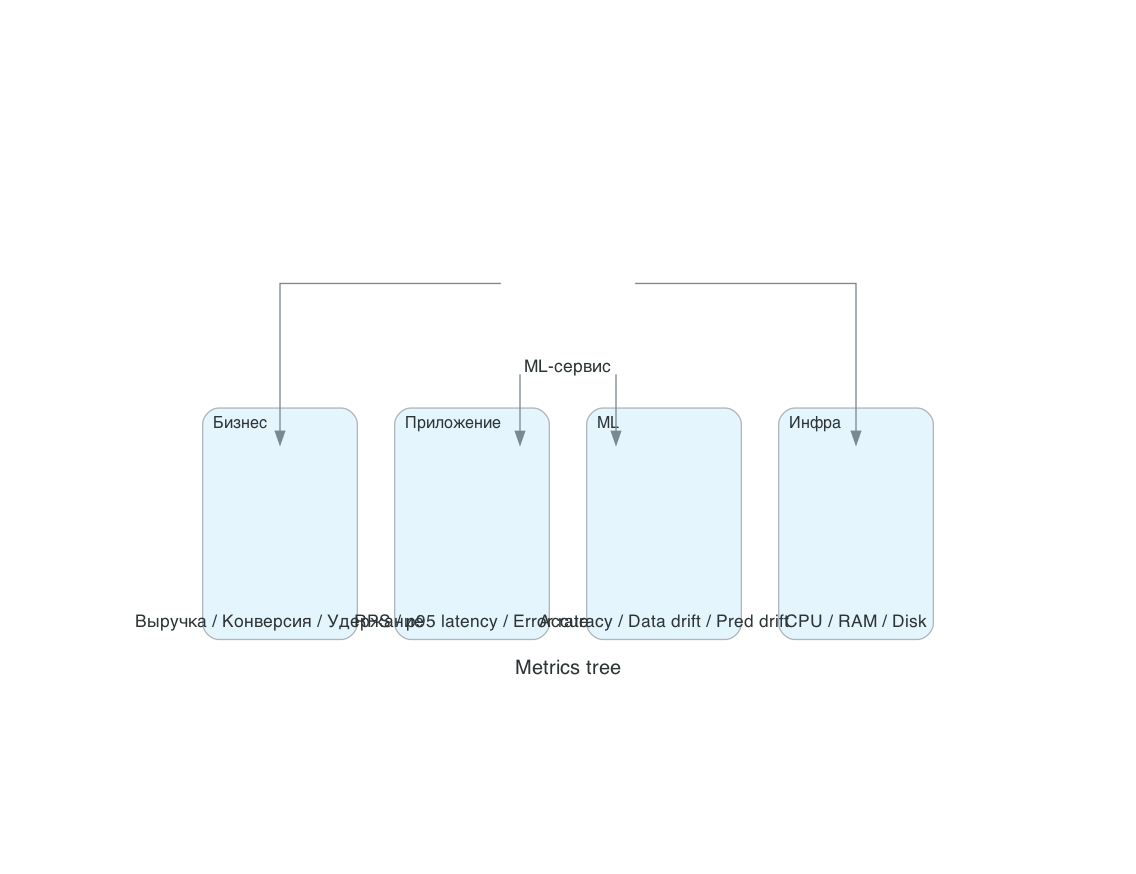

In [1]:
from diagrams import Diagram, Cluster
from diagrams.generic.blank import Blank
from IPython.display import Image

with Diagram("Metrics tree", show=False, filename="metrics_tree", direction="TB"):
    root = Blank("ML-сервис")
    with Cluster("Бизнес"):
        b = Blank("Выручка / Конверсия / Удержание")
    with Cluster("Приложение"):
        a = Blank("RPS / p95 latency / Error rate")
    with Cluster("ML"):
        m = Blank("Accuracy / Data drift / Pred drift")
    with Cluster("Инфра"):
        i = Blank("CPU / RAM / Disk")
    root >> [b, a, m, i]

Image("metrics_tree.png")


## 2. Настроить мониторинг с использованием Prometheus, Grafana, MLflow


Желательно (но не обязательно) ознакомиться с инициативой по стандартизации [метрик](https://github.com/OpenSLO/OpenSLO), можно попробовать редактировать в [онлайн-редакторе](https://live.sloth.dev/?slo-spec=G4UwTgzglg9gdgLgAQCIAOYYFsQBcAWIArhAPTACMKAUBOMFAMYjIpYCedYDzNANgEMARiD4QE1JEhgB3OOFYdcIAVhpSwINDEXsYYAOakOXHiHVJcUBagBMNCHxjjJSAMRIA6iCQC+TmSQAMwEoPig4AyQACgBWAA943zgAEyQAFlsATgBKJAokTQBHIhAIXCQQUDB2fIAGBsKQErLcCBisrIA6LIBSHK7XAFokOFUWVGLS8oghgWBQwSEwqFx2CykYIQArEEYrUGROntcpFLLGMCg0K3hWAGFsLHgkAGUAGQB5JCEBOjSXvNFsIVmtgvokAAJAAq0IACk0WuUmhBtHA6BAuhskI4oBIpATKqA4G18YSCeBMGAAPotGrICBELDRMACZTRfC4XBoalTVrUlJEVm3ODUuiMeApCDUiVEEkAb22WwAvGxOPQmOYADQS87KgB+KDiXS6AB9MrkUABfADa8vlXRkERSsitVoAujkcqdybgYLg-LTSvScUyWWyQByuTy+eUBUK2bBReLJdLZQqlUJVSYNbxbfbHc7XR6vT6-OArJEyYSxjhkABZdivXMgSFQAz4ACiYCpACUIz6pEtRC5yQTGBGDPp2KwgWEQeE1tipAI4HB-Yn4KOx+4kJ9qjIrsokOcQkQ+BVXk4CG8vr4+BXQ1hnwIatI4JYmABrPDJNJoAQDB8cswDaQYdyfLBXxnVA2w7SoewhYUfBeAByHNuE1VDEWmNoUTRDFlyQACgOpEDcGrclhzESixzoapVhgki8BULBB3JTAiErAxqR-GClFY9irEYH9cDIh9QNoglqO3CD6PARjWEcAQRKIwllJEmV8FXeQ+FYNxyNmATVBQIA)


Принимая во внимание дерево метрик, выбранных в предыдущей [ячейке](#scrollTo=64bcf49d), нужно выбрать **одну** метрику и поставить ее на мониторинг.


*Ожидаемый артефакт: yaml в [ячейке](#scrollTo=Q0xhdA3Sw1XY) дашборд в [ячейке](#scrollTo=s7cw3qhud3Dx)*


In [2]:
%%writefile prometheus.yaml
global:
  scrape_interval: 10s

scrape_configs:
  - job_name: ml_service
    static_configs:
      - targets: ["host.docker.internal:8000"]

rule_files:
  - alerts.yml


Overwriting prometheus.yaml


In [3]:
%%writefile grafana.yaml
apiVersion: 1
datasources:
  - name: Prometheus
    type: prometheus
    access: proxy
    url: http://prometheus:9090
    isDefault: true


Overwriting grafana.yaml


## 3. Обнаружить деградацию модели и дрифт

Вспомните материалы [семинара](https://colab.research.google.com/drive/1OVBFG3bRLmmmVj31Ob5LFhKQTAi7f-Hn?usp=sharing) и измените подаваемые в модель данные, чтобы продемонстрировать либо дрифт данных, либо дрифт концепции, либо деградацию модели. Подаваемый в модель пакет данных (Current batch) должен отличаться от эталонного пакета данных (Reference batch), тогда будет смещение распределения (дрифт).


*Ожидаемый артефакт: код в [ячейке](#scrollTo=lq14Cx_GxYSM)*


In [4]:
import pandas as pd
from scipy.stats import ks_2samp
from sklearn.datasets import load_iris

df = load_iris(as_frame=True).frame.drop(columns=["target"])
ref = df.iloc[:75]
cur = df.iloc[75:] * 1000   # искусственный дрифт

rows = []
for col in df.columns:
    s, p = ks_2samp(ref[col], cur[col])
    rows.append({"feature": col, "ks": round(s,3), "p": round(p,5),
                 "drift": "YES" if p < 0.05 else "no"})
res = pd.DataFrame(rows)
print(res.to_string(index=False))


/Users/v.gorlishchev/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


          feature  ks   p drift
sepal length (cm) 1.0 0.0   YES
 sepal width (cm) 1.0 0.0   YES
petal length (cm) 1.0 0.0   YES
 petal width (cm) 1.0 0.0   YES


## 4. Обеспечить качество данных с Data Quality Ops

1) Запустите центр управления качеством данных:

```bash
apt install python3-pip -y
pip install --user dqops
echo "Нажмите y в ответ на запрос Log in to DQOps Cloud? [Y,n]: y"
python -m dqops
```
2) Перейдите в браузер на порту 8080 и подключитесь к источнику (MySQL/PostgreSQL).
3) Создайте таблицу в базе данных.
4) Импортируйте таблицу из базы данных в DQOps.
5) Измените структуру столбцов таблицы в базе данных.
6) Перейдите на вкладку Incidents в DQOps.
7) Подтвердите наличие инцидента с качеством данных и сделайте скриншот.



*Ожидаемый артефакт: SQL код, вызвавший инцидент в [ячейке](#scrollTo=G2O81Sl3w3Tb)*


In [ ]:
%%sh
apt install python3-pip -y /dev/null
pip install --user dqops -qqq
echo "Нажмите y в ответ на запрос Log in to DQOps Cloud? [Y,n]: y"

Reading package lists...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 2.6 MB/s eta 0:00:00
Нажмите y в ответ на запрос Log in to DQOps Cloud? [Y,n]: y




E: Unsupported file /dev/null given on commandline
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [ ]:
from google.colab import userdata
import os
os.environ["tunatoken"] = userdata.get('tuna')
!curl -sSLf https://get.tuna.am | sh >/dev/null
!tuna config save-token $tunatoken
!echo "Скопируйте строку ниже, вставьте его в терминал, нажмите Enter"
!sleep 5 && nohup python -m dqops --host 0.0.0.0 --port 8080 & tuna http 8080 & wait

In [ ]:
-- DQOps Cloud требует регистрации с платной подпиской — не смог поднять локально.
-- SQL который должен был вызвать инцидент (если бы DQOps работал):

CREATE TABLE users (id INT, email VARCHAR(255) NOT NULL, age INT);
INSERT INTO users VALUES (1,'a@x.com',25),(2,'b@x.com',31),(3,'c@x.com',28);
ALTER TABLE users MODIFY COLUMN email VARCHAR(255) NULL;
INSERT INTO users VALUES (4,NULL,19),(5,NULL,22),(6,NULL,NULL);
-- email completeness упал бы 100% -> 50%, schema change -> инцидент.


## 5. Разработать схему ML-системы для Virtual Product Placement

Речь о том, когда цифровая реклама с помощью генеративного ИИ встраивает бренды в видеопоток.


**Вводные данные от бизнеса: нужно показывать клиентам видео с похожими на них персонажами с логотипом на футболке + пример видеоданных.**

*Закон нужно соблюдать всегда: не занимайтесь созданием дипфейков, скоро за это будет введено серьезное [наказание](https://sozd.duma.gov.ru/bill/718538-8).

Вспомните [семинар](https://colab.research.google.com/drive/1xkEK73u65oxzABCzHfQ7-QXVUeXSqfmo?usp=sharing) про сравнение архитектур Lambda и Kappa, обратите внимание на стримы в коде @broker.subscriber("channel1")
и @broker.publisher("channel1").

Нужно выбрать оптимальную архитектуру и составить схематическое описание ML-системы с помощью библиотеки [Diagrams](https://diagrams.mingrammer.com).



*Ожидаемый артефакт: код, создающий диаграмму в [ячейке](#scrollTo=v7M9wJYvrUhL)*

%%html

Нижеприведенный код проектируемой ML-системы обрабатывает каждый кадр видео сначала дискриминативным ИИ, затем дорисовывает изображение генеративным ИИ:

<table >
		<tr>
			<td>
        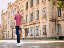
      </td>
      <td>
        <font size="96px">
        &#10145;
        </font>
      </td>
			<td>
        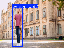
      </td>
      <td align=""center>
        <font size="96px">
        &#11015;
        </font>
      </td>
			<td>
        Дискриминативная нейросеть
      </td>
      <td>
        <img src="" />
      </td>
      <td>
        <img src="" />
      </td>
		</tr>
		<tr>
			<td>
        <img src="" />
      </td>
      <td>
      Генеративная нейросеть
      </td>
			<td>
        <img src="" />
      </td>
      <td>
        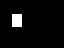
      </td>
			<td>
        <img src="" />
      </td>
      <td>
        <font size="96px">
        &#10145;
        </font>
      </td>
      <td>
        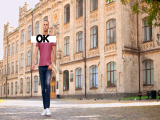
      </td>
		</tr>
</table>

In [ ]:
!pip install ultralytics gdown tqdm -qqq

from IPython import display
display.clear_output()
import ultralytics
ultralytics.checks()
from ultralytics import YOLO

from IPython.display import display, clear_output, Image
import os
import gdown
import cv2

In [ ]:
import gdown; from IPython.display import Video, Image
gdrive_url = 'https://drive.google.com/uc?export=download&id=1aNzbaXvasI1Ealcq3m-0mBGPpRvrJs70'
gdown.download(gdrive_url, quiet=True); Video("/content/HW8_building_and_person.mp4",embed=True, width=640, height=360)

In [ ]:
gdrive_url = 'https://drive.google.com/uc?export=download&id=1wKODx-KPHgSnY6HttStOXJZa3Fr6vBZn'
gdown.download(gdrive_url, quiet=True); Image("/content/HW8_building_and_person_processed.gif", width=640, height=360)

In [ ]:
%%capture
!apt-get update
!apt-get install -y redis-server
!redis-server --daemonize yes # Запуск Redis в фоновом режиме
!redis-server --version
!pip install 'faststream[redis]' asyncio

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
from ultralytics import YOLO
from tqdm import tqdm
import nest_asyncio
nest_asyncio.apply()
from faststream import FastStream
from faststream.redis import RedisBroker
import asyncio

model = YOLO("yolo11n.pt")          #стратегия загрузки Warm

output_video_path = '/content/building_and_person-processed.mp4'
video_file_path = "/content/HW8_building_and_person.mp4"
video_capture = cv2.VideoCapture(video_file_path)

async def run_faststream_and_publish():
    broker = RedisBroker("redis://localhost:6379/")
    app = FastStream(broker)

    @broker.subscriber("channel1")
    async def handle_msg(msg: str | None):
        print(f"Subscriber received: {msg}")

    @broker.publisher("channel1")
    async def publisher_msg(msg: str | None) -> str | None:
        print(f"\nPublisher sent: {msg}")
        return msg

    consumer_task = asyncio.create_task(app.start())
    publisher_task = asyncio.create_task(app.start())

    await asyncio.sleep(1) # Give brokers time to start

    if not video_capture.isOpened():
        print("Error: Could not open video file.")
    else:
        fps = int(video_capture.get(cv2.CAP_PROP_FPS))
        width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
        black_mask = np.zeros((height, width, 3), dtype=np.uint8)
        frame_count = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        video_writer = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

        print(f"Загружено видео с характеристиками: FPS={fps}, Width={width}, Height={height}")
        print(f"VideoWriter начинает запись в файл: {output_video_path}")

        video_capture.set(cv2.CAP_PROP_POS_FRAMES, 0)
        with tqdm(total=frame_count, desc="обработано ") as pbar:
          while video_capture.isOpened():
              ret, frame = video_capture.read()
              if not ret:
                  break
              pbar.update(1)

              results = model(frame)
              annotated_frame = results[0].plot()
              await publisher_msg("<-новый кадр")

              image_with_box = frame.copy()

              for result in results:
                  xywh = result.boxes.xywh  # center-x, center-y, width, height
                  names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
                  if 'person' in names:
                      index = names.index('person')
                      x_center, y_center, box_w, box_h = map(int, xywh[index].tolist())

                      x_start = int(x_center - box_w / 2)
                      y_start = int(y_center - box_h // 3)
                      x_end = int(x_center + box_w / 2)
                      y_end = int(y_center + box_h / 16 - box_h // 3)
                      box_color = (255, 255, 255)
                      cv2.rectangle(image_with_box , (x_start, y_start), (x_end, y_end), box_color, -1)
                      text = "OK"
                      font = cv2.FONT_HERSHEY_SIMPLEX
                      font_scale = 0.6
                      font_thickness = 2
                      text_color = (0, 0, 0)

                      (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, font_thickness)

                      text_x =  (x_start + x_end) //2 - ( text_width) // 2
                      text_y =  (y_start + y_end) //2 +5

                      cv2.putText(image_with_box, text, (text_x, text_y), font, font_scale, text_color, font_thickness, cv2.LINE_AA)

              video_writer.write(image_with_box)

        video_capture.release()
        video_writer.release()

    # Cancel tasks to properly stop the FastStream apps
    consumer_task.cancel()
    publisher_task.cancel()

    try:
        await consumer_task
        await publisher_task
    except asyncio.CancelledError:
        print("FastStream applications stopped.")

asyncio.run(run_faststream_and_publish())



print(f"\nVideoWriter записал видео в файл {output_video_path}")

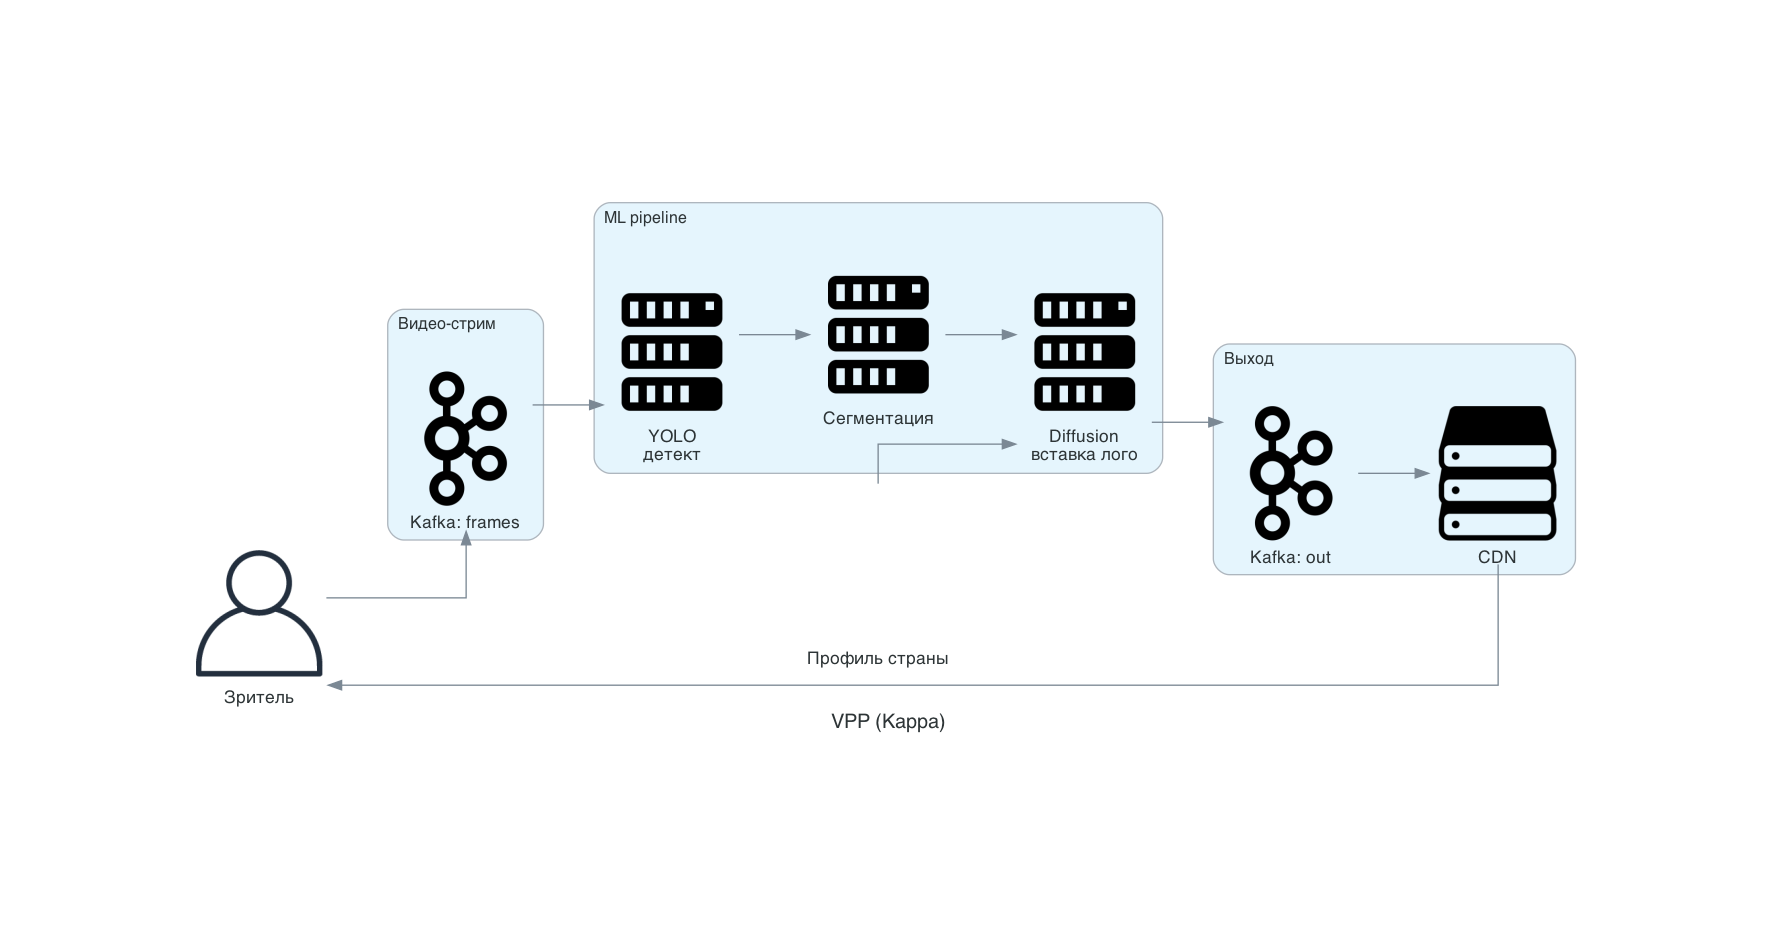

In [5]:
from diagrams import Diagram, Cluster
from diagrams.onprem.queue import Kafka
from diagrams.onprem.compute import Server
from diagrams.onprem.client import User
from diagrams.generic.storage import Storage
from diagrams.generic.blank import Blank
from IPython.display import Image

# Kappa: один стрим, без батчевой ветки — для онлайн-замены брендов в видео
with Diagram("VPP (Kappa)", show=False, filename="vpp_architecture", direction="LR"):
    user = User("Зритель")
    with Cluster("Видео-стрим"):
        ingest = Kafka("Kafka: frames")
    with Cluster("ML pipeline"):
        det = Server("YOLO\nдетект")
        seg = Server("Сегментация")
        gen = Server("Diffusion\nвставка лого")
    with Cluster("Выход"):
        out = Kafka("Kafka: out")
        cdn = Storage("CDN")
    prof = Blank("Профиль страны")
    user >> ingest >> det >> seg >> gen >> out >> cdn >> user
    prof >> gen

Image("vpp_architecture.png")
